In [1]:
import json

import agama
import gc_utils
import matplotlib.pyplot as plt
import numpy as np
import utilities as ut

In [2]:
def get_halo_center(part, halt, sim, sim_dir, snapshot):
    # check if centering should be on dm halo
    sim_codes = sim_dir + "simulation_codes.json"
    with open(sim_codes) as sim_json:
        sim_data = json.load(sim_json)
    main_halo_tid = sim_data[sim]["halo"]

    not_host_snap_lst = gc_utils.get_different_snap_lst(main_halo_tid, halt, sim, sim_dir)

    # is the MW progenitor is the main host at this snapshot
    is_main_host = snapshot not in not_host_snap_lst

    halt_center_snap_lst = sim_data[sim]["dm_center"]
    use_dm_center = snapshot in halt_center_snap_lst

    # if the halo is not the host at this snapshot or it has been flagged to use dm center at this snapshot
    if (not is_main_host) or (use_dm_center):
        # get MW progenitor halo details at this snapshot
        halo_tid = gc_utils.get_main_prog_at_snap(halt, main_halo_tid, snapshot)

        if use_dm_center:
            halo_detail_dict = gc_utils.get_dm_halo_details(part, halt, halo_tid, snapshot, True)
        else:
            halo_detail_dict = gc_utils.get_halo_details(part, halt, halo_tid, snapshot)

        return_dict = {"use_host_prop": False, "halo_details": halo_detail_dict}

    else:
        return_dict = {"use_host_prop": True}

    return return_dict

In [3]:
def calc_circularity(snap, pos_xyz, vel_xyz, sim, sim_dir):
    potential_file = sim_dir + sim + "/potentials/snap_%d/combined_snap_%d.ini" % (snap, snap)

    agama.setUnits(mass=1, length=1, velocity=1)
    pot_nbody = agama.Potential(potential_file)
    af = agama.ActionFinder(pot_nbody, interp=False)

    init_cond = np.hstack((pos_xyz, vel_xyz))

    ioms = af(init_cond)
    jphi = ioms[:, 2]

    ep_agama = pot_nbody.potential(np.array(init_cond)[:, 0:3])
    ek = 0.5 * np.linalg.norm(vel_xyz, axis=1) ** 2
    et = ep_agama + ek

    r_circs = pot_nbody.Rcirc(E=et)
    xyz = np.column_stack((r_circs, r_circs * 0, r_circs * 0))
    v_circs = np.sqrt(-r_circs * pot_nbody.force(xyz)[:, 0])
    vel = np.column_stack((v_circs * 0, v_circs, v_circs * 0))
    init_conds = np.concatenate((xyz, vel), axis=1)
    lz_circ = af(init_conds)[:, 2]

    circ = jphi / lz_circ

    return circ

In [4]:
def get_circularity(
    halt,
    part,
    sim: str,
    sim_dir: str,
    snapshot: int,
    r_limit: float,
    disk_ptypes: list[str] = ["star", "gas"],
    log_t_max: float = 4.5,
):
    host_return_dict = get_halo_center(part, halt, sim, sim_dir, snapshot)

    # create dict
    circ_dict = {}

    if "star" in disk_ptypes:
        if host_return_dict["use_host_prop"]:
            # only select stars within r_limit
            star_mask = part["star"].prop("host.distance.principal.total") < r_limit

            # get 3D positions and velocities
            vel_xyz_star = part["star"].prop("host.velocity.principal")[star_mask]
            pos_xyz_star = part["star"].prop("host.distance.principal")[star_mask]

            # star mass
            star_mass = part["star"]["mass"][star_mask]

        else:
            halo_detail_dict = host_return_dict["halo_details"]

            # only select stars within r_limit
            star_pos_mask = (
                ut.particle.get_distances_wrt_center(
                    part,
                    species=["star"],
                    center_position=halo_detail_dict["position"],
                    rotation=halo_detail_dict["rotation"],
                    coordinate_system="cartesian",
                    total_distance=True,
                )
                < r_limit
            )

            # get 3D positions and velocities
            vel_xyz_star = ut.particle.get_velocities_wrt_center(
                part,
                species=["star"],
                center_position=halo_detail_dict["position"],
                center_velocity=halo_detail_dict["velocity"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_velocity=False,
            )[star_pos_mask]

            pos_xyz_star = ut.particle.get_distances_wrt_center(
                part,
                species=["star"],
                center_position=halo_detail_dict["position"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_distance=False,
            )[star_pos_mask]

            # star mass
            star_mass = part["star"]["mass"][star_pos_mask]

        circ_star = calc_circularity(snapshot, pos_xyz_star, vel_xyz_star, sim, sim_dir)

        circ_dict["star"] = {}
        circ_dict["star"]["mass"] = star_mass
        circ_dict["star"]["circularity"] = circ_star

    if "gas" in disk_ptypes:
        # only select gas particles within r_limit
        gas_tem_mask = np.log10(part["gas"]["temperature"]) < log_t_max

        if host_return_dict["use_host_prop"]:
            # only select gas within r_limit
            gas_pos_mask = part["gas"].prop("host.distance.principal.total") < r_limit

            # get 3D positions and velocities
            vel_xyz_gas = part["gas"].prop("host.velocity.principal")[gas_pos_mask & gas_tem_mask]
            pos_xyz_gas = part["gas"].prop("host.distance.principal")[gas_pos_mask & gas_tem_mask]

            # gas mass
            gas_mass = part["gas"]["mass"][gas_pos_mask & gas_tem_mask]

        else:
            halo_detail_dict = host_return_dict["halo_details"]

            # only select gas within r_limit
            gas_pos_mask = (
                ut.particle.get_distances_wrt_center(
                    part,
                    species=["gas"],
                    center_position=halo_detail_dict["position"],
                    rotation=halo_detail_dict["rotation"],
                    coordinate_system="cartesian",
                    total_distance=True,
                )
                < r_limit
            )

            # get 3D positions and velocities
            vel_xyz_gas = ut.particle.get_velocities_wrt_center(
                part,
                species=["gas"],
                center_position=halo_detail_dict["position"],
                center_velocity=halo_detail_dict["velocity"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_velocity=False,
            )[gas_pos_mask & gas_tem_mask]

            pos_xyz_gas = ut.particle.get_distances_wrt_center(
                part,
                species=["gas"],
                center_position=halo_detail_dict["position"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_distance=False,
            )[gas_pos_mask & gas_tem_mask]

            # gas mass
            gas_mass = part["gas"]["mass"][gas_pos_mask & gas_tem_mask]

        circ_gas = calc_circularity(snapshot, pos_xyz_gas, vel_xyz_gas, sim, sim_dir)

        circ_dict["gas"] = {}
        circ_dict["gas"]["mass"] = gas_mass
        circ_dict["gas"]["circularity"] = circ_gas

    return circ_dict

In [6]:
sim = "m12b"
# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"
fire_dir = sim_dir + sim + "/" + sim + "_res7100"

# halt = gc_utils.get_halo_tree(sim, sim_dir, species="star")
halt = gc_utils.get_halo_tree(sim, sim_dir)

Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:31<00:00, 31.07s/it]


In [7]:
r_lim = 5  # kpc
snaps = [120, 142, 172, 214, 277]

In [8]:
snap_dict = {}
for snap in snaps:
    snap_id = gc_utils.snapshot_name(snap)

    part = gc_utils.open_snapshot(snap, fire_dir, ["star"])
    circ_dict = get_circularity(halt, part, sim, sim_dir, snap, r_lim, disk_ptypes="star")
    snap_dict[snap_id] = circ_dict

Retrieving Snapshot 277..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:07<00:00,  7.82s/it]


In [9]:
ptypes = ["star"]
# ptypes = ["gas"]
# ptypes = ["star", "gas"]

circ_bins = np.arange(-1, 1.1, 0.1)
circ_bins = np.array([-1, 0.2, 0.8, 1])
circ_centres = 0.5 * (circ_bins[:-1] + circ_bins[1:])
circ_bin_num = len(circ_bins) - 1

mass_bins = np.zeros((len(snaps), circ_bin_num))

for i, snap in enumerate(snaps):
    snap_id = gc_utils.snapshot_name(snap)

    total_mass = 0
    for ptype in ptypes:
        total_mass += np.sum(snap_dict[snap_id][ptype]["mass"])

    for j in range(circ_bin_num):
        circ_min = circ_bins[j]
        circ_max = circ_bins[j + 1]

        bin_mass = 0
        for ptype in ptypes:
            ptype_circ = snap_dict[snap_id][ptype]["circularity"]
            ptype_mass = snap_dict[snap_id][ptype]["mass"]

            circ_msk = (circ_min < ptype_circ) & (ptype_circ <= circ_max)
            bin_mass += np.sum(ptype_mass[circ_msk])

        mass_bins[i, j] = bin_mass / total_mass

Text(0.5, 1.0, 'Stars')

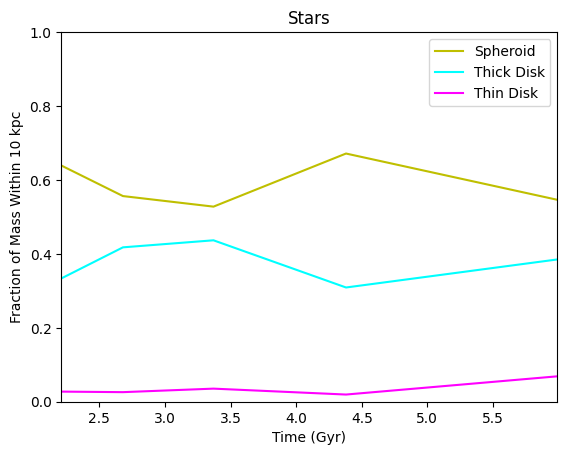

In [11]:
# x = [4.38, 5.98, 6.43, 6.90, 7.42, 8.05]
x = [2.21, 2.68, 3.37, 4.38, 5.99]

spheroid = mass_bins[:, 0]
thick_disk = mass_bins[:, 1]
thin_disk = mass_bins[:, 2]

plt.plot(x, spheroid, c="y", label="Spheroid")
plt.plot(x, thick_disk, c="cyan", label="Thick Disk")
plt.plot(x, thin_disk, c="magenta", label="Thin Disk")

plt.xlabel("Time (Gyr)")
plt.ylabel("Fraction of Mass Within 10 kpc")

plt.xlim(np.min(x), np.max(x))
plt.ylim(0, 1)

plt.legend()
# plt.title("Stars and Gas")
plt.title("Stars")

In [18]:
r_lim = 5  # kpc
snaps = [214, 277, 294, 312, 332, 356]

snap_dict_05 = {}
for snap in snaps:
    snap_id = gc_utils.snapshot_name(snap)

    part = gc_utils.open_snapshot(snap, fire_dir, ["star", "gas"])
    circ_dict = get_circularity(halt, part, sim, sim_dir, snap, r_lim)
    snap_dict_05[snap_id] = circ_dict

Retrieving Snapshot 214..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:53<00:00, 53.99s/it]


KeyboardInterrupt: 

In [ ]:
# ptypes = ["star"]
# ptypes = ["gas"]
ptypes = ["star", "gas"]

circ_bins = np.arange(-1, 1.1, 0.1)
circ_bins = np.array([-1, 0.2, 0.8, 1])
circ_centres = 0.5 * (circ_bins[:-1] + circ_bins[1:])
circ_bin_num = len(circ_bins) - 1

mass_bins = np.zeros((len(snaps), circ_bin_num))

for i, snap in enumerate(snaps):
    snap_id = gc_utils.snapshot_name(snap)

    total_mass = 0
    for ptype in ptypes:
        total_mass += np.sum(snap_dict_05[snap_id][ptype]["mass"])

    for j in range(circ_bin_num):
        circ_min = circ_bins[j]
        circ_max = circ_bins[j + 1]

        bin_mass = 0
        for ptype in ptypes:
            ptype_circ = snap_dict_05[snap_id][ptype]["circularity"]
            ptype_mass = snap_dict_05[snap_id][ptype]["mass"]

            circ_msk = (circ_min < ptype_circ) & (ptype_circ <= circ_max)
            bin_mass += np.sum(ptype_mass[circ_msk])

        mass_bins[i, j] = bin_mass / total_mass

Text(0.5, 1.0, 'Stars and Gas')

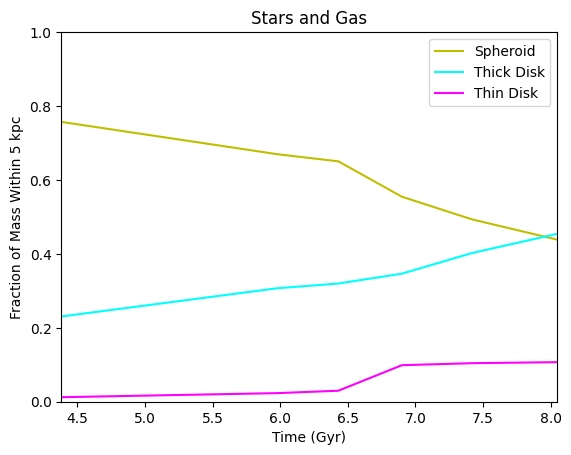

In [ ]:
x = [4.38, 5.98, 6.43, 6.90, 7.42, 8.05]

spheroid = mass_bins[:, 0]
thick_disk = mass_bins[:, 1]
thin_disk = mass_bins[:, 2]

plt.plot(x, spheroid, c="y", label="Spheroid")
plt.plot(x, thick_disk, c="cyan", label="Thick Disk")
plt.plot(x, thin_disk, c="magenta", label="Thin Disk")

plt.xlabel("Time (Gyr)")
plt.ylabel("Fraction of Mass Within 5 kpc")

plt.xlim(np.min(x), np.max(x))
plt.ylim(0, 1)

plt.legend()
plt.title("Stars and Gas")